<a href="https://colab.research.google.com/github/ayushman-c/kaggle-notebooks/blob/main/Explanatory/Titanic_Dataset/notebooks/improved_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction - Model Improvement

In this notebook, we improve the baseline model by:

- Performing feature engineering to
- Training a more powerful model (Random Forest)
- Comparing the performance with Logistic Regression

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/cleaned_titanic.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
df["FamilySize"] = df["SibSp"] + df["Parch"]+1
df["isAlone"] = (df["FamilySize"] == 1).astype(int)

In [48]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,isAlone
0,0,3,0,34.5,0,0,7.8292,True,False,1,1
1,1,3,1,47.0,1,0,7.0000,False,True,2,0
2,0,2,0,62.0,0,0,9.6875,True,False,1,1
3,0,3,0,27.0,0,0,8.6625,False,True,1,1
4,1,3,1,22.0,1,1,12.2875,False,True,3,0


##Feature Engineering

We introduced new features:

- FamiltySize : Total number of family members onboard
- IsAlone : Indicates whether the passenger was travelling alone

These features help capture social dynamics

In [49]:
# Dropping 'Sex' because it has a 1.0 correlation with the target, causing leakage
X = df.drop(["Survived", "Sex"], axis=1)
y = df["Survived"]

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)


In [51]:
from sklearn.linear_model import LogisticRegression

LogR = LogisticRegression(max_iter=1000)
LogR.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=50)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=50)

## Model Selection
We use random forest because:
- It captures non linear relationships
- It handels feature interaction
- Performs well on LogisticRegression

In [53]:
from sklearn.metrics import accuracy_score

y_pred_logR = LogR.predict(X_test)
y_pred_rf = rf.predict(X_test)

acc1 = accuracy_score(y_test, y_pred_logR)
acc2 = accuracy_score(y_test, y_pred_rf)

print("Accuracy of Logistic Regression: ", acc1)
print("Accuracy of Random Forest: ", acc2)

Accuracy of Logistic Regression:  0.6071428571428571
Accuracy of Random Forest:  0.6309523809523809


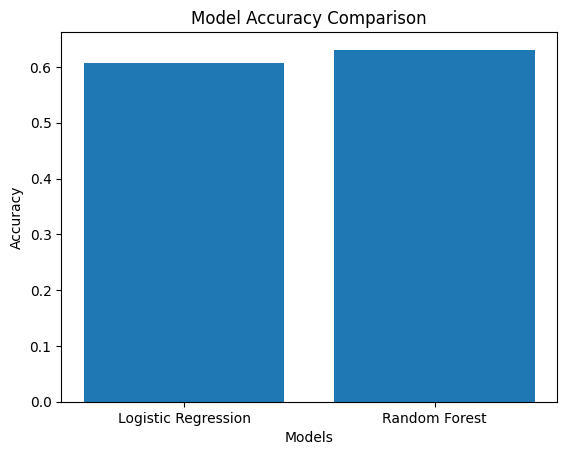

In [54]:
models = ["Logistic Regression", "Random Forest"]
accuracies = [acc1, acc2]

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [55]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_

}).sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
1,Age,0.354512
4,Fare,0.338063
7,FamilySize,0.063102
3,Parch,0.047417
0,Pclass,0.046531
5,Embarked_Q,0.039814
2,SibSp,0.037947
6,Embarked_S,0.037189
8,isAlone,0.035425


##Feature Selection

Random Forest provides feature importance scores, showing which variables most influence survival prediction.

This helps interpret the model and understand key factors.